# Driving Style Clustering on Waymo (WOMD)

Waymo-specific copy of `driving_style_clustering.ipynb`. Differences vs the AV2 notebook:

- Loads `artifacts/phase1_waymo/tables/waymo_val_feature_table.csv` (no Waymo *train* extraction was run; only the validation split exists).
- Splits the Waymo val table **80/20 by `scenario_id`** so every agent from a scenario stays on one side (no leakage). The "train" side is just more val data used to fit cleaning stats / scaler / K-means.
- Looser stop-and-go and physical-sanity thresholds — Waymo's raw finite-difference signals are noticeably noisier than AV2 (max_abs_jerk has a tail past 2000 m/s³, max_abs_accel past 140 m/s²).

Outputs go to `artifacts/clustering_waymo/`.

In [1]:
from __future__ import annotations
import sys, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from tailrisk_mp.cleaning import CleaningConfig, filter_for_clustering

warnings.filterwarnings('ignore', category=FutureWarning)

RANDOM_STATE = 42
TRAIN_FRACTION = 0.8   # 80/20 by scenario_id

TABLES        = REPO_ROOT / 'artifacts' / 'phase1_waymo' / 'tables'
WAYMO_VAL_CSV = TABLES / 'waymo_val_feature_table.csv'

OUT_DIR = REPO_ROOT / 'artifacts' / 'clustering_waymo'
FIG_DIR = OUT_DIR / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Waymo val CSV:', WAYMO_VAL_CSV, '| exists:', WAYMO_VAL_CSV.exists())
print('Outputs      :', OUT_DIR)

Waymo val CSV: /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/phase1_waymo/tables/waymo_val_feature_table.csv | exists: True
Outputs      : /fs/nexus-projects/pc_driving/yaghoubi/tail-risk-motion-prediction/artifacts/clustering_waymo


## 1. Load Waymo val table and split 80/20 by scenario_id

Each row is one *center agent* in one scenario. The Waymo train split was never extracted (storage / time), so we split the validation table by `scenario_id` to form pseudo-train and val sets — all agents from one scenario stay together to avoid leakage. The "train" side is just more val data used to fit cleaning stats / scaler / K-means.

In [2]:
full = pd.read_csv(WAYMO_VAL_CSV)
print('Full Waymo val rows:', len(full), '| unique scenarios:', full['scenario_id'].nunique())

rng = np.random.default_rng(RANDOM_STATE)
scenarios = np.array(sorted(full['scenario_id'].unique()))
rng.shuffle(scenarios)
n_train = int(round(len(scenarios) * TRAIN_FRACTION))
train_sids = set(scenarios[:n_train])
val_sids   = set(scenarios[n_train:])
train_raw = full[full['scenario_id'].isin(train_sids)].reset_index(drop=True).copy()
val_raw   = full[full['scenario_id'].isin(val_sids)].reset_index(drop=True).copy()
train_raw['split'] = 'train'
val_raw['split']   = 'val'

print(f'Scenario-level split: {len(train_sids)} train / {len(val_sids)} val scenarios')
print('train_raw:', train_raw.shape)
print('val_raw  :', val_raw.shape)
train_raw.head(3)

Full Waymo val rows: 164660 | unique scenarios: 43763
Scenario-level split: 35010 train / 8753 val scenarios
train_raw: (131673, 53)
val_raw  : (32987, 53)


,dataset,split,scenario_id,center_objects_id,center_objects_type,trajectory_type,kalman_difficulty_2s,kalman_difficulty_4s,kalman_difficulty_6s,avg_speed,...,neighbor_count_30m,min_neighbor_distance,inverse_min_neighbor_distance,max_closing_speed,min_ttc,inverse_min_ttc,close_encounter_count,cv_ade,cv_fde,cv_miss_rate
0,waymo,train,b0feee255709211c,265,1,5,2.330725,9.253762,-1.000000,3.734341,...,4.0,7.293017,0.137117,0.0,inf,0.0,0,6.548152,19.598501,1.0
1,waymo,train,5b6e16614f5c47b5,748,1,7,7.500162,18.559371,29.798558,0.706075,...,2.0,27.830442,0.035932,0.0,inf,0.0,0,8.175771,19.033524,1.0
2,waymo,train,a1aa1cedb8b12d5d,497,1,1,4.114283,11.395991,-1.000000,15.821236,...,9.0,8.082329,0.123727,0.0,inf,0.0,0,4.757945,13.012796,1.0


## 2. Pre-cluster cleaning

Drops:
- `is_stationary` rows (parked / idling - no driving style),
- short tracks (< 30 valid future steps),
- non-vehicle agents,
- NaN feature rows,
- percentile-clip outliers (0.1 / 99.9) and Mahalanobis outliers.

Stats are *fit on train* and *applied to val* so val is not contaminated.

In [3]:
cfg_train = CleaningConfig(fit_stats=True)
train_clean, train_report = filter_for_clustering(train_raw, cfg_train,
    report_path=OUT_DIR / 'cleaning_report_train.json')

cfg_val = CleaningConfig(fit_stats=False, reuse_stats=train_report['clean_stats'])
val_clean, val_report = filter_for_clustering(val_raw, cfg_val,
    report_path=OUT_DIR / 'cleaning_report_val.json')

def drop_table(rep):
    rows = [{'reason': k, 'count': v, 'fraction': rep['drop_fractions'][k]}
            for k, v in rep['drop_counts'].items()]
    rows.append({'reason': 'KEPT', 'count': rep['kept_rows'], 'fraction': rep['kept_fraction']})
    return pd.DataFrame(rows)

print('Train  ', train_raw.shape[0], '->', train_clean.shape[0])
print('Val    ', val_raw.shape[0],   '->', val_clean.shape[0])
print('\nTrain drop table:')
print(drop_table(train_report).to_string(index=False))

Train   131673 -> 128369
Val     32987 -> 32161

Train drop table:
                 reason  count  fraction
             stationary   1512  0.011483
            short_track      7  0.000053
            non_vehicle      0  0.000000
            nan_feature      0  0.000000
percentile_clip_outlier    488  0.003706
    outlier_mahalanobis   1297  0.009850
                   KEPT 128369  0.974908


### 2b. Stop-and-go filter

Even after the standard cleaning, agents that spend most of the window stopped and then accelerate (e.g. waiting at a traffic light, then green-light departure) get inflated `*_jerk` / `hard_accel_count` and end up in the aggressive cluster - even though their motion is normal.

We drop those by requiring the agent to be *consistently moving*:

- `avg_speed >= MIN_AVG_SPEED` (default 3.0 m/s) - rules out long-idle windows.
- `avg_speed / max_speed >= MIN_SPEED_RATIO` (default 0.4) - rules out the classic stop-then-go shape, where avg << max.

Both thresholds are reported and easy to tune.

In [4]:
# Waymo-specific defaults: looser than AV2 because the avg/max ratio is mostly
# 0.5-0.9 anyway (see histogram), so we only need to reject the obvious stop-go
# tail rather than gating everything moderately variable.
MIN_AVG_SPEED   = 3.0   # m/s (~11 km/h)
MIN_SPEED_RATIO = 0.3   # avg_speed / max_speed - reject only the strong stop-then-go tail

def drop_stopgo(df, name):
    n0 = len(df)
    speed_ratio = df['avg_speed'] / df['max_speed'].replace(0, np.nan)
    keep = (df['avg_speed'] >= MIN_AVG_SPEED) & (speed_ratio >= MIN_SPEED_RATIO)
    out = df.loc[keep].copy()
    print(f'{name:5s}  {n0} -> {len(out)}  '
          f'(dropped {n0 - len(out)}, {(n0 - len(out)) / max(n0, 1):.1%})')
    return out

train_clean = drop_stopgo(train_clean, 'train')
val_clean   = drop_stopgo(val_clean,   'val')

train  128369 -> 101341  (dropped 27028, 21.1%)
val    32161 -> 25513  (dropped 6648, 20.7%)


### 2c. Physical-sanity filter (Waymo-tuned)

Waymo's raw finite-difference jerk/accel are noticeably noisier than AV2 (likely the position polylines themselves have higher noise / different sampling). The histograms in the previous cells show:

- `max_abs_accel` peaks ~5-10 m/s² with a tail past 140 m/s²
- `max_abs_jerk`  peaks ~100 m/s³ with a tail past 2000 m/s³

So the AV2 limits (12 / 50) would drop most rows. The bounds below are scaled up so we only chop the most extreme tail (~5-10 % of rows). Tune `PHYSICAL_LIMITS` as you wish; setting any value to `None` disables that check.

<Axes: >

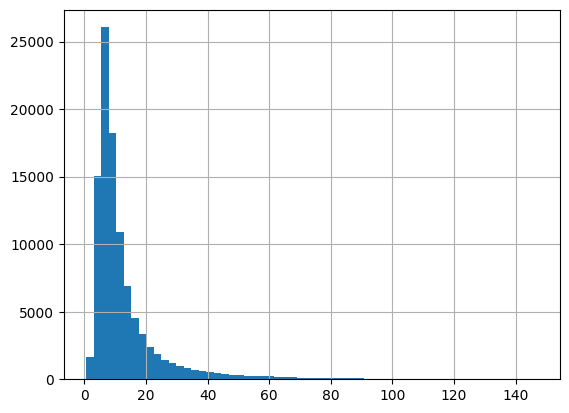

In [7]:
train_clean['max_abs_accel'].hist(bins=60)

In [8]:
# Waymo-tuned upper bounds.
# AV2 reference (for comparison):
#   max_abs_accel=12, max_abs_jerk=50, max_abs_lat_accel=10, max_abs_heading_rate=3
PHYSICAL_LIMITS = {
    'max_speed':             40.0,    # m/s  - 145 km/h
    'max_abs_accel':         40.0,    # m/s^2
    'max_abs_long_accel':    40.0,
    'max_abs_lat_accel':     40.0,
    'max_abs_jerk':          500.0,   # m/s^3
    'max_abs_long_jerk':     500.0,
    'max_abs_lat_jerk':      500.0,
    'max_abs_heading_rate':   5.0,    # rad/s - ~290 deg/s; very high, only rejects glitches
    'max_abs_heading_delta':  1.8,    # rad / step
}

def drop_unphysical(df, name, limits=PHYSICAL_LIMITS):
    n0 = len(df)
    keep = pd.Series(True, index=df.index)
    per_feature: list[dict] = []
    for feat, lim in limits.items():
        if lim is None or feat not in df.columns:
            continue
        bad = df[feat].abs() > lim
        per_feature.append({'feature': feat, 'limit': lim,
                            'dropped': int((bad & keep).sum())})
        keep &= ~bad
    out = df.loc[keep].copy()
    print(f'\n{name}  {n0} -> {len(out)}  '
          f'(dropped {n0 - len(out)}, {(n0 - len(out)) / max(n0, 1):.1%})')
    print(pd.DataFrame(per_feature).to_string(index=False))
    return out

train_clean = drop_unphysical(train_clean, 'train')
val_clean   = drop_unphysical(val_clean,   'val')


train  101341 -> 90128  (dropped 11213, 11.1%)
              feature  limit  dropped
            max_speed   40.0        0
        max_abs_accel   40.0     4593
   max_abs_long_accel   40.0        0
    max_abs_lat_accel   40.0        0
         max_abs_jerk  500.0     2852
    max_abs_long_jerk  500.0        0
     max_abs_lat_jerk  500.0        0
 max_abs_heading_rate    5.0     3768
max_abs_heading_delta    1.8        0

val  25513 -> 22728  (dropped 2785, 10.9%)
              feature  limit  dropped
            max_speed   40.0        0
        max_abs_accel   40.0     1131
   max_abs_long_accel   40.0        0
    max_abs_lat_accel   40.0        0
         max_abs_jerk  500.0      722
    max_abs_long_jerk  500.0        0
     max_abs_lat_jerk  500.0        0
 max_abs_heading_rate    5.0      932
max_abs_heading_delta    1.8        0


## 3. Candidate feature pool

All numeric kinematic features that describe *how* an agent moves (no model-side / dataset-bookkeeping columns).
Heading-change-signed is dropped because we want magnitude-based behavior, not turn direction.

In [9]:
# Lateral / braking / steady-state features only.
# Pure longitudinal accel/jerk and hard_accel_count are excluded because a single
# stop->go transient inflates them, even after the stop-and-go cleaning step.
CANDIDATE_FEATURES = [
    # speed (sustained / spread)
    'avg_speed', 'max_speed', 'var_speed',
    # lateral acceleration (cornering load)
    'avg_lat_accel', 'max_abs_lat_accel',
    # lateral jerk (steering aggressiveness)
    'avg_lat_jerk', 'max_abs_lat_jerk',
    # heading & curvature (turn sharpness)
    'heading_change_abs', 'max_abs_heading_delta', 'max_abs_heading_rate',
    'curvature_proxy', 'gamma',
    # braking-only event features (genuine hard braking, NOT green-light starts)
    'hard_brake_count', 'lateral_g_spike_count',
    # path geometry
    'displacement', 'path_length',
]
CANDIDATE_FEATURES = [f for f in CANDIDATE_FEATURES if f in train_clean.columns]
print(len(CANDIDATE_FEATURES), 'candidate features (lateral / braking / steady-state)')

16 candidate features (lateral / braking / steady-state)


## 4. Feature importance

Three complementary scores so we are not relying on one heuristic:

1. **Standardized variance / IQR** - features that are constant give clusters nothing to grip on.
2. **Mutual information vs aggressiveness proxy** - we define a binary proxy from event counts (`hard_brake_count + hard_accel_count + lateral_g_spike_count + high_jerk_count` >= 1) and rank features by MI against it. This is *only* a ranking signal; we do **not** use this proxy as the cluster label.
3. **Random-Forest feature importance** against the same proxy.

Final selection = top-N by an averaged rank across the three scores.

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

X_all = train_clean[CANDIDATE_FEATURES].astype(float).to_numpy()
scaler_all = StandardScaler().fit(X_all)
Xs = scaler_all.transform(X_all)

# 1. variance after standardisation (IQR is more robust)
iqr = np.subtract(*np.percentile(Xs, [75, 25], axis=0))

# 2. aggressiveness proxy: braking + lateral spike events only.
# (hard_accel_count and high_jerk_count are excluded because they fire on green-light starts.)
proxy_event_cols = [c for c in ['hard_brake_count', 'lateral_g_spike_count']
                    if c in train_clean.columns]
y_proxy = (train_clean[proxy_event_cols].sum(axis=1) >= 1).astype(int).to_numpy()
print('Proxy events:', proxy_event_cols, '| positive rate:', y_proxy.mean().round(3))

# subsample for MI / RF speed
rng = np.random.default_rng(RANDOM_STATE)
n_sub = min(15000, len(Xs))
idx = rng.choice(len(Xs), size=n_sub, replace=False)

mi = mutual_info_classif(Xs[idx], y_proxy[idx], random_state=RANDOM_STATE, n_neighbors=5)
rf = RandomForestClassifier(n_estimators=200, max_depth=8, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(Xs[idx], y_proxy[idx])

imp_df = pd.DataFrame({
    'feature': CANDIDATE_FEATURES,
    'iqr_std': iqr,
    'mutual_info': mi,
    'rf_importance': rf.feature_importances_,
})
for col in ['iqr_std', 'mutual_info', 'rf_importance']:
    imp_df[col + '_rank'] = imp_df[col].rank(ascending=False)
imp_df['avg_rank'] = imp_df[['iqr_std_rank', 'mutual_info_rank', 'rf_importance_rank']].mean(axis=1)
imp_df = imp_df.sort_values('avg_rank').reset_index(drop=True)
imp_df.to_csv(OUT_DIR / 'feature_importance.csv', index=False)
imp_df.head(15)

Proxy events: ['hard_brake_count', 'lateral_g_spike_count'] | positive rate: 0.942


,feature,iqr_std,mutual_info,rf_importance,iqr_std_rank,mutual_info_rank,rf_importance_rank,avg_rank
0,hard_brake_count,1.328654,0.151881,0.471397,3.0,1.0,1.0,1.666667
1,max_abs_lat_accel,0.952439,0.079015,0.138664,10.0,4.0,2.0,5.333333
2,heading_change_abs,1.453164,0.032124,0.026176,1.0,8.0,8.0,5.666667
3,lateral_g_spike_count,0.978440,0.056336,0.096184,9.0,5.0,3.0,5.666667
4,gamma,0.935017,0.096622,0.085124,12.0,2.0,4.0,6.000000
5,max_abs_lat_jerk,0.945795,0.080010,0.083930,11.0,3.0,5.0,6.333333
6,avg_speed,1.323553,0.005191,0.004004,4.0,12.0,11.0,9.000000
7,max_abs_heading_rate,0.836435,0.035669,0.034464,14.0,7.0,6.0,9.000000
8,max_speed,1.385798,0.004954,0.003058,2.0,13.0,13.0,9.333333
9,max_abs_heading_delta,0.836435,0.035709,0.026843,15.0,6.0,7.0,9.333333


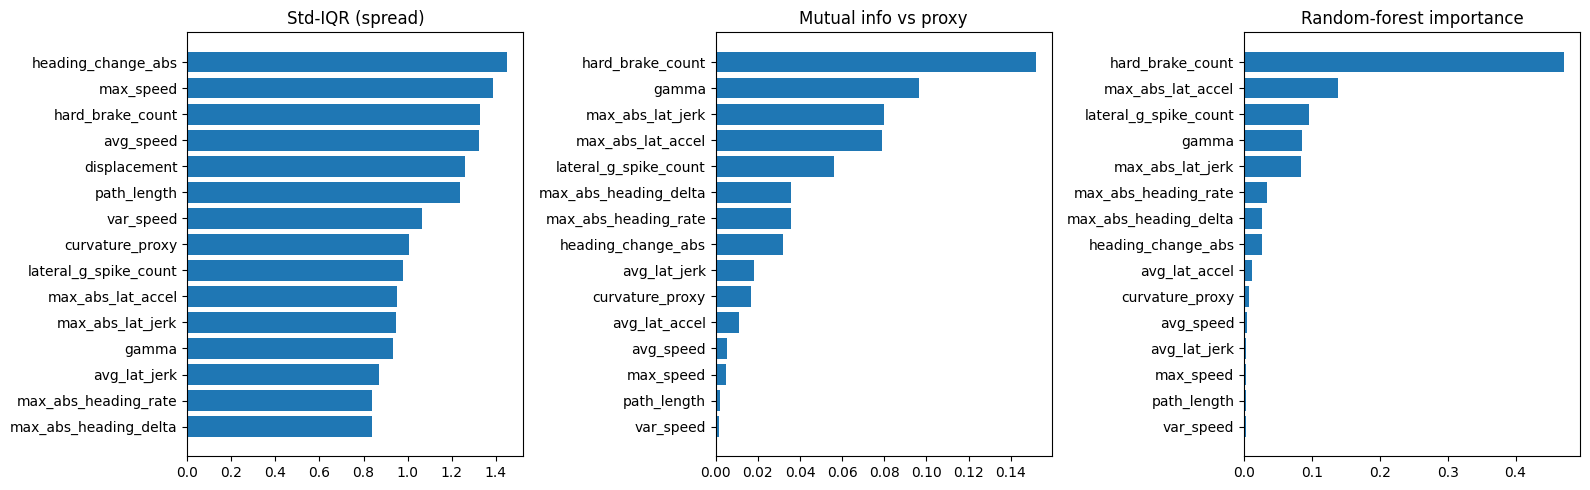

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in zip(
    axes,
    ['iqr_std', 'mutual_info', 'rf_importance'],
    ['Std-IQR (spread)', 'Mutual info vs proxy', 'Random-forest importance'],
):
    sub = imp_df.sort_values(col, ascending=True).tail(15)
    ax.barh(sub['feature'], sub[col])
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIG_DIR / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

### Pick the clustering features

Top-N by averaged rank. Drop near-duplicates (e.g. avg_jerk vs avg_long_jerk) by keeping only the higher-ranked of each correlated pair.

In [12]:
TOP_N = 8
CORR_THRESHOLD = 0.92

ranked = imp_df['feature'].tolist()
selected: list[str] = []
for feat in ranked:
    if len(selected) >= TOP_N:
        break
    keep = True
    if selected:
        corr = train_clean[selected + [feat]].corr().iloc[-1, :-1].abs()
        if (corr > CORR_THRESHOLD).any():
            keep = False
    if keep:
        selected.append(feat)

CLUSTER_FEATURES = selected
print('Selected for clustering:')
for f in CLUSTER_FEATURES:
    print(' -', f)

Selected for clustering:
 - hard_brake_count
 - max_abs_lat_accel
 - heading_change_abs
 - lateral_g_spike_count
 - gamma
 - max_abs_lat_jerk
 - avg_speed
 - max_abs_heading_rate


## 5. K=2 K-means clustering

Fit `StandardScaler + KMeans(K=2)` on cleaned train, apply to val. The cluster with the higher mean on aggressive-leaning features is labelled `aggressive`.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

K = 2

Xtr = train_clean[CLUSTER_FEATURES].astype(float).to_numpy()
Xva = val_clean[CLUSTER_FEATURES].astype(float).to_numpy()

scaler = StandardScaler().fit(Xtr)
Xtr_s = scaler.transform(Xtr)
Xva_s = scaler.transform(Xva)

km = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(Xtr_s)
tr_lbl = km.labels_
va_lbl = km.predict(Xva_s)

# Label which cluster is aggressive: pick the one with higher mean on lateral / braking signals.
aggressive_signals = [f for f in [
    'max_abs_lat_accel', 'max_abs_lat_jerk', 'lateral_g_spike_count',
    'hard_brake_count', 'max_abs_heading_rate', 'gamma',
] if f in train_clean.columns]
if not aggressive_signals:
    aggressive_signals = CLUSTER_FEATURES[:1]
print('Cluster-labelling signals:', aggressive_signals)

score_per_cluster = (
    train_clean.assign(_c=tr_lbl)
               .groupby('_c')[aggressive_signals]
               .mean()
               .mean(axis=1)
)
agg_cluster = int(score_per_cluster.idxmax())
label_map = {agg_cluster: 'aggressive', 1 - agg_cluster: 'normal'}
print('Cluster -> label:', label_map)

train_clean = train_clean.copy()
val_clean   = val_clean.copy()
train_clean['cluster_id_K2'] = tr_lbl
val_clean['cluster_id_K2']   = va_lbl
train_clean['style_label']   = pd.Series(tr_lbl, index=train_clean.index).map(label_map)
val_clean['style_label']     = pd.Series(va_lbl, index=val_clean.index).map(label_map)

print('\nTrain cluster sizes:')
print(train_clean['style_label'].value_counts())
print('\nVal cluster sizes:')
print(val_clean['style_label'].value_counts())

# internal metrics on a sample (silhouette is O(n^2))
sub = rng.choice(len(Xtr_s), size=min(8000, len(Xtr_s)), replace=False)
metrics = {
    'silhouette': float(silhouette_score(Xtr_s[sub], tr_lbl[sub])),
    'davies_bouldin': float(davies_bouldin_score(Xtr_s, tr_lbl)),
    'calinski_harabasz': float(calinski_harabasz_score(Xtr_s, tr_lbl)),
    'n_train': int(len(tr_lbl)), 'n_val': int(len(va_lbl)),
    'features': CLUSTER_FEATURES, 'label_map': {int(k): v for k, v in label_map.items()},
}
print('\nInternal metrics:', metrics)

with open(OUT_DIR / 'clustering_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
with open(OUT_DIR / 'kmeans_K2.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'model': km, 'features': CLUSTER_FEATURES,
                 'label_map': {int(k): v for k, v in label_map.items()}}, f)

Cluster-labelling signals: ['max_abs_lat_accel', 'max_abs_lat_jerk', 'lateral_g_spike_count', 'hard_brake_count', 'max_abs_heading_rate', 'gamma']
Cluster -> label: {0: 'aggressive', 1: 'normal'}

Train cluster sizes:
style_label
normal        66244
aggressive    23884
Name: count, dtype: int64

Val cluster sizes:
style_label
normal        16681
aggressive     6047
Name: count, dtype: int64

Internal metrics: {'silhouette': 0.3391982515215804, 'davies_bouldin': 1.4670943581649718, 'calinski_harabasz': 32739.544851852002, 'n_train': 90128, 'n_val': 22728, 'features': ['hard_brake_count', 'max_abs_lat_accel', 'heading_change_abs', 'lateral_g_spike_count', 'gamma', 'max_abs_lat_jerk', 'avg_speed', 'max_abs_heading_rate'], 'label_map': {0: 'aggressive', 1: 'normal'}}


## 6. Cluster profile - is the 'aggressive' cluster actually aggressive?

Per-cluster means on a wider set of behaviour features, normalized to z-scores so we can read which signals dominate.

In [14]:
PROFILE_FEATURES = list(dict.fromkeys(
    CLUSTER_FEATURES + [
        'avg_speed', 'max_speed', 'max_abs_accel', 'max_abs_jerk',
        'hard_brake_count', 'hard_accel_count', 'lateral_g_spike_count', 'high_jerk_count',
        'max_abs_long_accel', 'max_abs_lat_accel', 'gamma',
    ]
))
PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in train_clean.columns]

z = (train_clean[PROFILE_FEATURES] - train_clean[PROFILE_FEATURES].mean()) / train_clean[PROFILE_FEATURES].std()
z['style_label'] = train_clean['style_label']
profile = z.groupby('style_label')[PROFILE_FEATURES].mean().T
profile['delta'] = profile.get('aggressive', 0) - profile.get('normal', 0)
profile = profile.sort_values('delta', ascending=False)
profile.to_csv(OUT_DIR / 'cluster_profile.csv')
profile.round(3)

style_label,aggressive,normal,delta
lateral_g_spike_count,1.139,-0.411,1.550
max_abs_lat_accel,1.070,-0.386,1.455
heading_change_abs,1.044,-0.377,1.421
max_abs_heading_rate,0.983,-0.354,1.337
max_abs_lat_jerk,0.933,-0.337,1.270
max_abs_accel,0.682,-0.246,0.928
max_abs_jerk,0.660,-0.238,0.898
max_abs_long_accel,0.610,-0.220,0.829
gamma,0.595,-0.215,0.810
hard_accel_count,0.479,-0.173,0.651


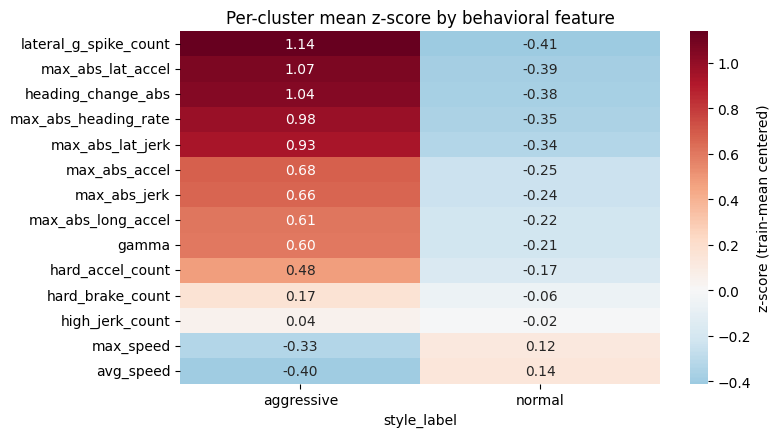

In [15]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.32 * len(PROFILE_FEATURES))))
sns.heatmap(profile.drop(columns='delta'), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'z-score (train-mean centered)'})
ax.set_title('Per-cluster mean z-score by behavioral feature')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_profile_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

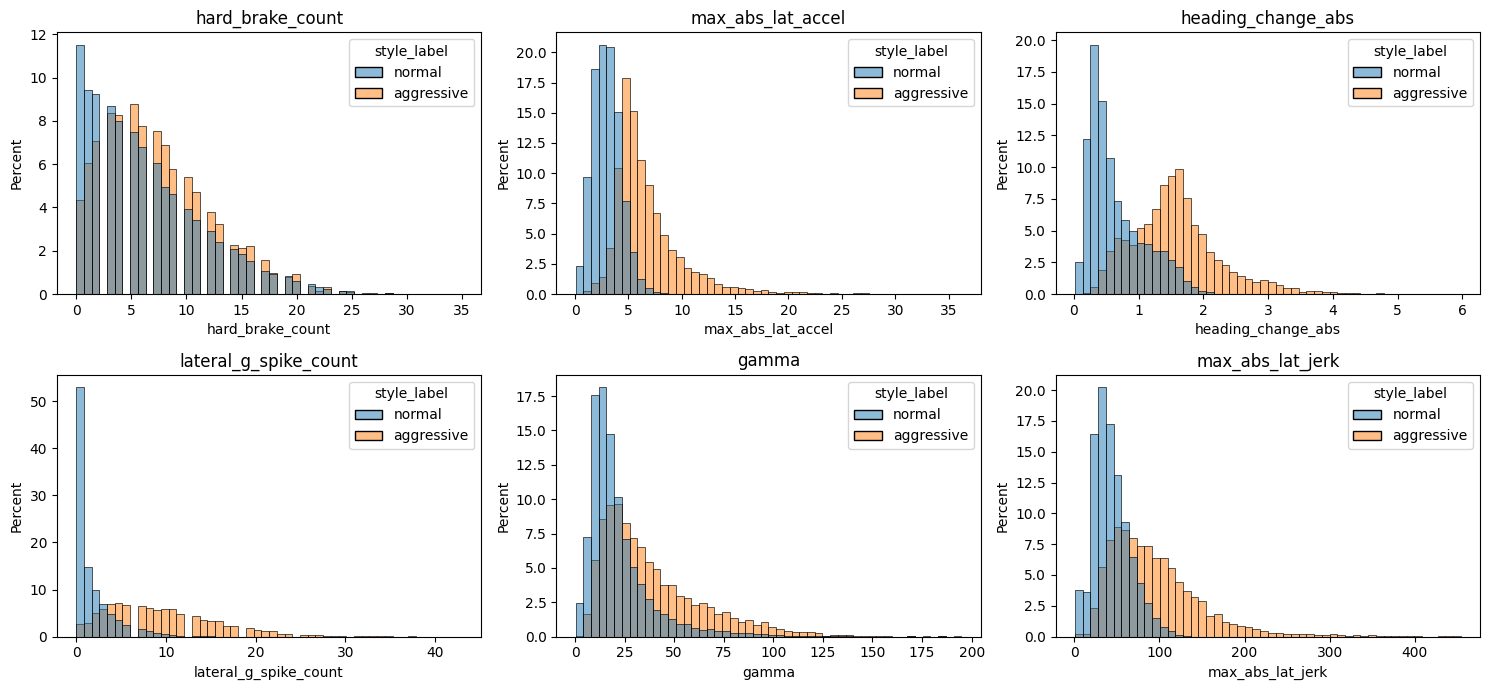

In [16]:
# Quick visual: kinematic distributions per cluster (val)
n_show = min(6, len(CLUSTER_FEATURES))
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.flat, CLUSTER_FEATURES[:n_show]):
    sns.histplot(data=val_clean, x=feat, hue='style_label', stat='percent',
                 common_norm=False, bins=50, ax=ax)
    ax.set_title(feat)
for ax in axes.flat[n_show:]:
    ax.set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'cluster_distributions_val.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Save labelled tables

These parquets are the input to the GIF notebook (`driving_style_gifs.ipynb`).

In [17]:
train_clean.to_parquet(OUT_DIR / 'waymo_train_clustered.parquet', index=False)
val_clean.to_parquet  (OUT_DIR / 'waymo_val_clustered.parquet',   index=False)
print('Wrote:')
for p in OUT_DIR.glob('*'):
    print(' ', p.relative_to(REPO_ROOT))

Wrote:
  artifacts/clustering_waymo/cleaning_report_train.json
  artifacts/clustering_waymo/cleaning_report_val.json
  artifacts/clustering_waymo/cluster_profile.csv
  artifacts/clustering_waymo/clustering_metrics.json
  artifacts/clustering_waymo/feature_importance.csv
  artifacts/clustering_waymo/figures
  artifacts/clustering_waymo/kmeans_K2.pkl
  artifacts/clustering_waymo/waymo_train_clustered.parquet
  artifacts/clustering_waymo/waymo_val_clustered.parquet
